# Plot browser tracks

In [20]:
here::i_am("rna_atac/clustering/04b_browser_tracks.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [21]:
args = list()

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [22]:
# Load ArchRproject (For genome annotation)
ArchRProject <- suppressMessages(ArchR::loadArchRProject(io$archR.directory))

args$atlas_bws = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/GroupBigWigs/celltype_genotype/'
atlas_celltypes = c('Primitive_Streak', 
              'Nascent_mesoderm', 
              'Allantois',
              'Endothelium'
             )
atlas_files = paste0(args$atlas_bws, atlas_celltypes, '.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw')

args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')
vitro_files = paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))

In [37]:
bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[genotype == 'WT'] %>% 
                .[, color := ifelse(genotype=='WT', opts$celltype_v2.colors[celltype], color)] %>% 
                .[, name := gsub('Haematoendothelial_progenitors', 'HE_progenitors', celltype)] %>% 
                .[, name := str_replace_all(name, opts$celltype_v2_figure)]

bigwigs.data_vivo = data.table(celltype = gsub(args$atlas_bws, '', atlas_files) %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = 'Atlas',
                    path =  atlas_files) %>% 
                .[,name := gsub('_', ' ', paste0(celltype, ' (Atlas)'))] %>% 
                .[,color := opts$celltype.colors[celltype]]

bigwigs.data = rbind(bigwigs.data_vitro, bigwigs.data_vivo)

bw_list = lapply(bigwigs.data$path, function(x)return(x))
names(bw_list) = bigwigs.data$name

In [38]:
opts$celltype_v2.colors2

PGC           Allantois Allantois Precursor          Mesenchyme 
          "#FACB12"           "#532C8A"           "#8870ad"           "#cc7818" 
      Posterior Mes        Early-Mes #1    Primitive Streak        Early-Mes #2 
          "#ffbfd0"           "#a0d0fa"           "#DABE99"           "#fc4c5c" 
       HE Precursor                  HE         Endothelium    Blood Progenitor 
          "#917057"           "#FBBE92"           "#ff891c"           "#f9decf"

In [41]:
bigwig_order = c('Primitive Streak (Atlas)','Primitive Streak',
                 'Nascent mesoderm (Atlas)','Early-Mes #1','Early-Mes #2',
                 'Posterior Mes','Allantois Precursor',
                 'Allantois (Atlas)','Allantois',
                 'Mesenchyme',
                 'HE Precursor','HE',
                 'Endothelium (Atlas)','Endothelium',
                 'Blood Progenitor',
                 'PGC'   
                )

# bigwig_order = c('Primitive_Streak (Atlas)','Primitive_Streak',
#                  'Nascent_mesoderm (Atlas)','Early_Mes_EOi','Early_Mes_EOd',
#                  'Endothelium (Atlas)','Endothelium',
#                  'Allantois (Atlas)','Allantois'
#                 )

WT_plot = bigwigs.data %>% copy() %>%
    .[match(bigwig_order, name)] 

In [42]:
WT_plot

celltype,genotype,path,color,name
<chr>,<chr>,<chr>,<chr>,<chr>
Primitive_Streak,Atlas,/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/GroupBigWigs/celltype_genotype/Primitive_Streak.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#DABE99,Primitive Streak (Atlas)
Primitive_Streak,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#DABE99,Primitive Streak
Nascent_mesoderm,Atlas,/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/GroupBigWigs/celltype_genotype/Nascent_mesoderm.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#C594BF,Nascent mesoderm (Atlas)
Early_Mes_EOi,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#a0d0fa,Early-Mes #1
Early_Mes_EOd,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOd.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#fc4c5c,Early-Mes #2
Posterior_Mes,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Posterior_Mes.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#ffbfd0,Posterior Mes
Allantois_Precursor,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Allantois_Precursor.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#8870ad,Allantois Precursor
Allantois,Atlas,/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/GroupBigWigs/celltype_genotype/Allantois.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#532C8A,Allantois (Atlas)
Allantois,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Allantois.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,#532C8A,Allantois


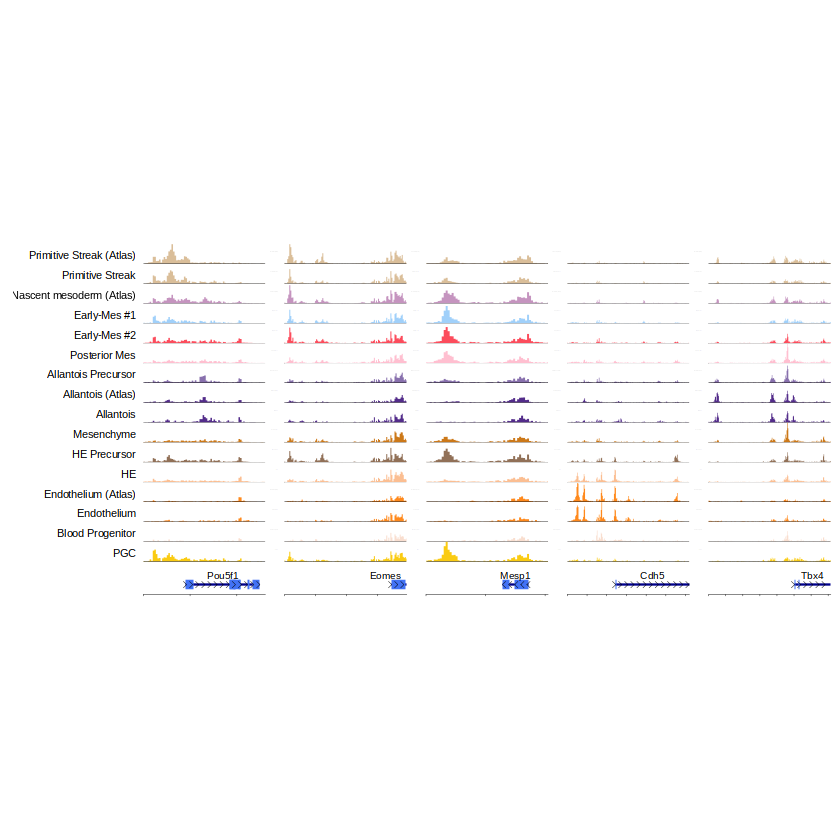

In [43]:
source(here::here('utils.R'))
heights = 4.2
gene_heights = 6
width = 9
downsample = 0.01
p1 = plot_browser_track(gene = NULL, input_region = 'chr17:35503295-35511133', bigwigs = WT_plot, extend.upstream = 0, extend.downstream = 0, downsample.rate = downsample, bw_height = heights, gene_height=gene_heights)
p2 = plot_browser_track(gene = NULL, input_region = 'chr9:118467852-118479695', bigwigs = WT_plot, extend.upstream = 0, extend.downstream = 0, downsample.rate = downsample, no_label = T, bw_height = heights, gene_height=gene_heights)
p3 = plot_browser_track(gene = NULL, input_region = 'chr7:79788409-79794564', bigwigs = WT_plot, extend.upstream = 0, extend.downstream = 0, downsample.rate = downsample, no_label = T, bw_height = heights, gene_height=gene_heights)
p4 = plot_browser_track(gene = NULL, input_region = 'chr8:104094306-104112911', bigwigs = WT_plot, extend.upstream = 0, extend.downstream = 0, downsample.rate = downsample, no_label = T, bw_height = heights, gene_height=gene_heights)
p5 = plot_browser_track(gene = NULL, input_region = 'chr11:85875007-85896484', bigwigs = WT_plot, extend.upstream = 0, extend.downstream = 0, downsample.rate = downsample, no_label = T, bw_height = heights, gene_height=gene_heights)

p = patchwork::wrap_plots(plotlist = list(p1,
                                      p2,
                                      p3,
                                      p4,
                                      p5), 
                                      nrow = 1)
p



In [48]:
ggsave(file.path(io$basedir, 'figures/multiome_celltype_genome_browser.pdf'), 
       plot = p,
       width = 160,  # Need to make wider and then remove blank areas in AI since ggplot is annoying about blank facet strip texts
       height = 80, 
       units = "mm")